# Retrivers

### A retrieveris a component in LangChain that fetches relevant documentsfrom a data source in response to a user’s query.
### There are multiple types of retrievers
### All retrievers in LangChain are runnables

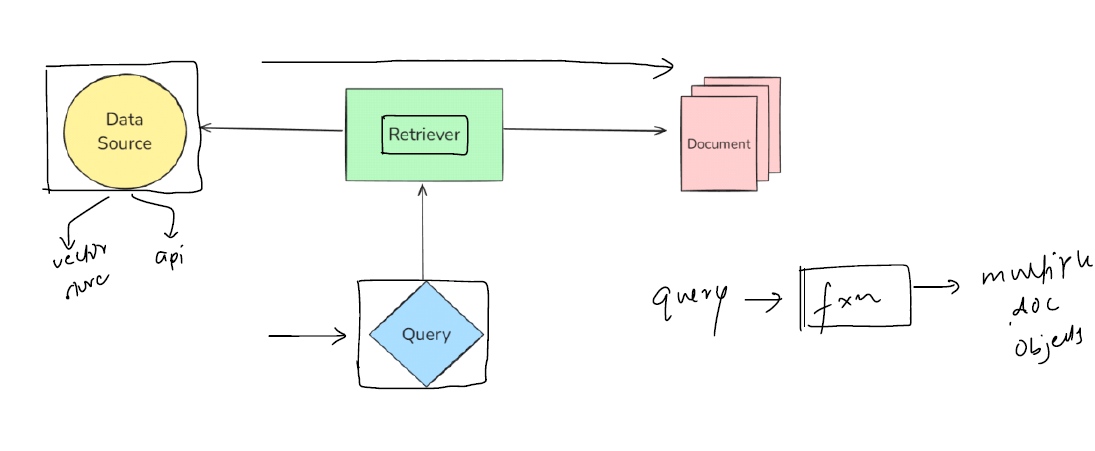

## Types of Retrievers

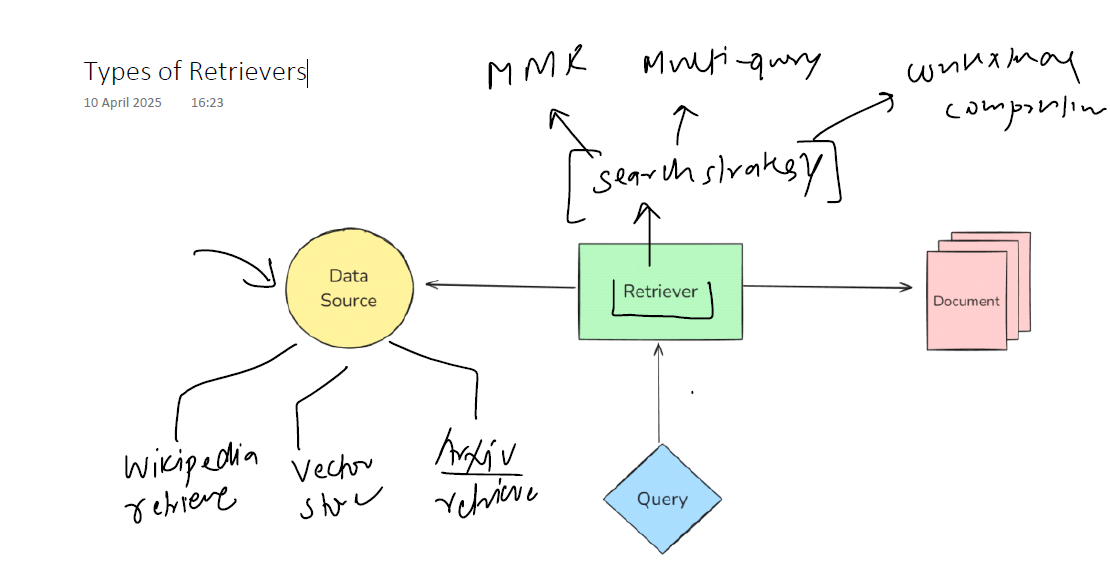

# Wikipedia Retriever

> A Wikipedia Retriever is a retriever that queries the Wikipedia API to fetch relevant content for a given query.

## 🔧 How It Works

1. You give it a query (e.g., `"Albert Einstein"`)
2. It sends the query to Wikipedia's API
3. It retrieves the **most relevant articles**
4. It returns them as LangChain `Document` objects

### Flow

```text
Input
  ↓
Wikipedia API
  ↓
Relevant articles
  ↓
LangChain Document objects


In [6]:
from langchain_community.retrievers import WikipediaRetriever

retriever = WikipediaRetriever(
    top_k_results=3,
    lang="en",
)

docs = retriever.invoke(input = 'who is the steve smith')

for doc in docs:
    print("TITLE:", doc.metadata.get("title"))
    print("CONTENT:", doc.page_content[:500])
    print("-" * 50)


TITLE: Steve Smith Sr.
CONTENT: Stevonne Latrall Smith Sr. (born May 12, 1979), better known as Steve Smith, is an American former professional football wide receiver who played in the National Football League (NFL) for 16 seasons, primarily with the Carolina Panthers. He played college football for the Utah Utes and was selected by the Panthers in the third round of the 2001 NFL draft. Smith spent 13 seasons in Carolina and three with the Baltimore Ravens. After retiring from the NFL, Smith became a sports analyst and show ho
--------------------------------------------------
TITLE: Steve Smith (cricketer)
CONTENT: Steven Peter Devereux Smith (born 2 June 1989) is an Australian international cricketer, former captain of the Australian national team in all three formats of the game and since 2021, the vice-captain of the Australian Test team. He is regarded as the best Test batsman of his generation, scoring over 10,000 Test runs, having reached an ICC Test batting rating of 947, the s

# Vector Store Retriever


A **Vector Store Retriever** in LangChain is the most common type of retriever that lets you search and fetch documents from a **vector store** based on **semantic similarity** using **vector embeddings**.

## ⚙️ How It Works

1. You store your documents in a **vector store** (like FAISS, Chroma, Weaviate).

2. Each document is converted into a **dense vector** using an **embedding model**.

3. When the user enters a **query**:
   - It's also turned into a **vector**.
   - The retriever compares the query vector with the stored vectors.
   - It retrieves the **top-k most similar ones**.


# 1. Install

In [ ]:
# !pip install -U langchain langchain-openai langchain-chroma

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

# 2. Create documents

In [8]:
from langchain_core.documents import Document

documents = [
    Document(
        page_content="LangChain is a framework for building LLM applications."
    ),  
    Document(
        page_content="Python is a popular programming language for AI and machine learning."
    ),
    Document(
        page_content="Chroma is a vector database used for semantic search."
    ),
]


# 3. Create embeddings

In [9]:
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(
    model='text-embedding-3-small'
)

# 4. Store them in a vector store

In [12]:
from langchain_chroma import Chroma
vector_store = Chroma.from_documents(documents=documents,embedding=embeddings,collection_name='my_documents')

# 5. Convert the vector store into a retriever

In [14]:
retriever = vector_store.as_retriever(search_type ='similarity',search_kwargs={'k':3})

# 6. Search with the retriever

In [15]:
query = 'what can i use for the similarity search.'

result = retriever.invoke(query)

In [16]:
for doc in result:
    print(doc.page_content)

Chroma is a vector database used for semantic search.
LangChain is a framework for building LLM applications.
Python is a popular programming language for AI and machine learning.
